
# Visualizing Trends in Python

This notebook is a simple Python conversion of the uploaded R Markdown file.
It uses basic Python packages and keeps the ideas student-friendly.



## Install packages
Run this cell once if needed.


In [7]:

!pip install  yfinance pydataset


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 9.2 MB/s eta 0:00:0000:0100:01m
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=2e8c8f24e3244893c8ebcc612f66a133fe34974667ac11cb1d67d14f5b8d1731
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


## Import libraries

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.optimize import curve_fit
from pydataset import data
import yfinance as yf

sns.set_theme(style="whitegrid")



## 1. Smoothing a time series
We start with the Dow Jones Industrial Average and compare the raw series with moving averages.


In [46]:
dow=pd.read_csv('/kaggle/input/datasets/eimieimieimi86/time-series/Dow_Jones_data.csv')
dow['date'] = pd.to_datetime(dow['date'])
start_date = "2008-12-31"
end_date = "2010-01-10"
dow = dow[(dow['date'] >= start_date) & (dow['date'] <= end_date)] # Get subset if the data between 2008 to 2010


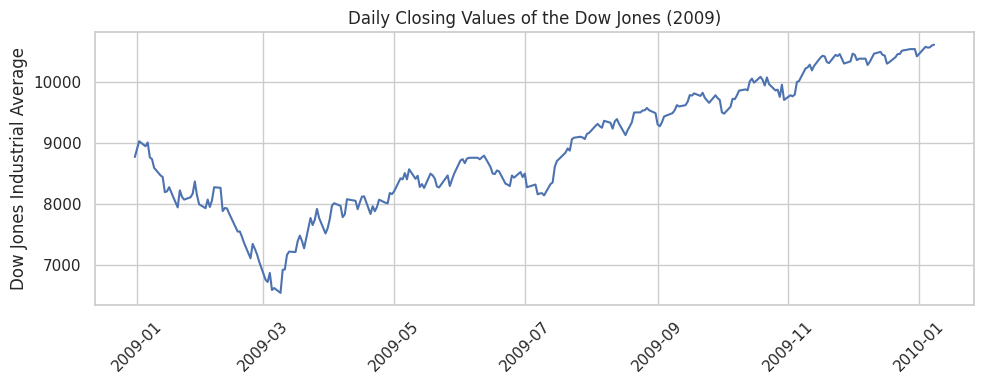

In [48]:

plt.figure(figsize=(10, 4))
plt.plot(dow["date"], dow["close"])
plt.xlabel("")
plt.ylabel("Dow Jones Industrial Average")
plt.title("Daily Closing Values of the Dow Jones (2009)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Moving averages

In [50]:

dow["ma_20"] = dow["close"].rolling(20).mean()
dow["ma_50"] = dow["close"].rolling(50).mean()
dow["ma_100"] = dow["close"].rolling(100).mean()

dow


,date,close,ma_20,ma_50,ma_100
0,2008-12-31,8776.389648,NaN,NaN,NaN
1,2009-01-02,9034.690430,NaN,NaN,NaN
2,2009-01-05,8952.889648,NaN,NaN,NaN
3,2009-01-06,9015.099609,NaN,NaN,NaN
4,2009-01-07,8769.700195,NaN,NaN,NaN
...,...,...,...,...,...
253,2010-01-04,10583.959961,10441.464453,10278.248184,9956.495947
254,2010-01-05,10572.019531,10450.620410,10288.062383,9968.600039
255,2010-01-06,10573.679688,10459.798877,10300.092383,9980.354932
256,2010-01-07,10606.860352,10475.843408,10314.870391,9993.209531


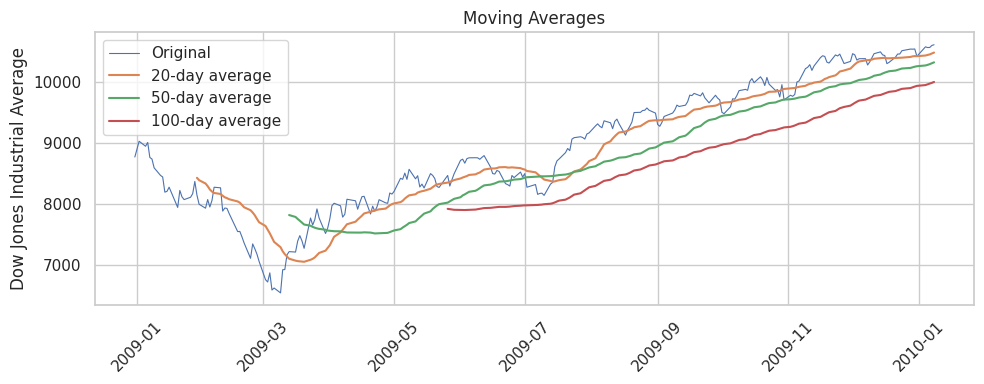

In [51]:

plt.figure(figsize=(10, 4))
plt.plot(dow["date"], dow["close"], linewidth=0.8, label="Original")
plt.plot(dow["date"], dow["ma_20"], label="20-day average")
plt.plot(dow["date"], dow["ma_50"], label="50-day average")
plt.plot(dow["date"], dow["ma_100"], label="100-day average")
plt.xlabel("")
plt.ylabel("Dow Jones Industrial Average")
plt.title("Moving Averages")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### LOESS smoother

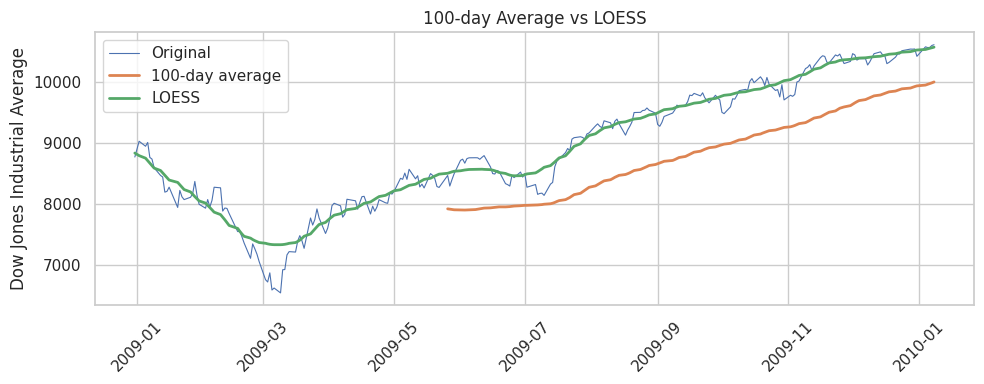

In [52]:

# LOWESS/LOESS smoothing
x_num = np.arange(len(dow))
loess_curve = lowess(dow["close"], x_num, frac=0.15)

plt.figure(figsize=(10, 4))
plt.plot(dow["date"], dow["close"], linewidth=0.8, label="Original")
plt.plot(dow["date"], dow["ma_100"], linewidth=2, label="100-day average")
plt.plot(dow["date"], loess_curve[:, 1], linewidth=2, label="LOESS")
plt.xlabel("")
plt.ylabel("Dow Jones Industrial Average")
plt.title("100-day Average vs LOESS")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 2. LOESS on scatter data
The R file used the `Cars93` dataset. Here we use the same dataset from `pydataset`.


In [53]:

cars93 = data("Cars93")
cars93 = cars93[["Price", "Fuel.tank.capacity"]].dropna()
cars93.head()


,Price,Fuel.tank.capacity
1,15.9,13.2
2,33.9,18.0
3,29.1,16.9
4,37.7,21.1
5,30.0,21.1


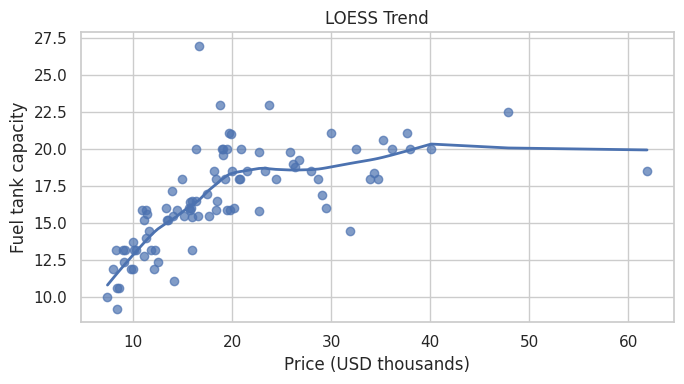

In [54]:

# LOESS for scatter data
loess_scatter = lowess(cars93["Fuel.tank.capacity"], cars93["Price"], frac=0.4)

plt.figure(figsize=(7, 4))
plt.scatter(cars93["Price"], cars93["Fuel.tank.capacity"], alpha=0.7)
plt.plot(loess_scatter[:, 0], loess_scatter[:, 1], linewidth=2)
plt.xlabel("Price (USD thousands)")
plt.ylabel("Fuel tank capacity")
plt.title("LOESS Trend")
plt.tight_layout()
plt.show()



## 6. Time-series decomposition
The original R file used atmospheric CO2 data. Python has a built-in version in `statsmodels`.


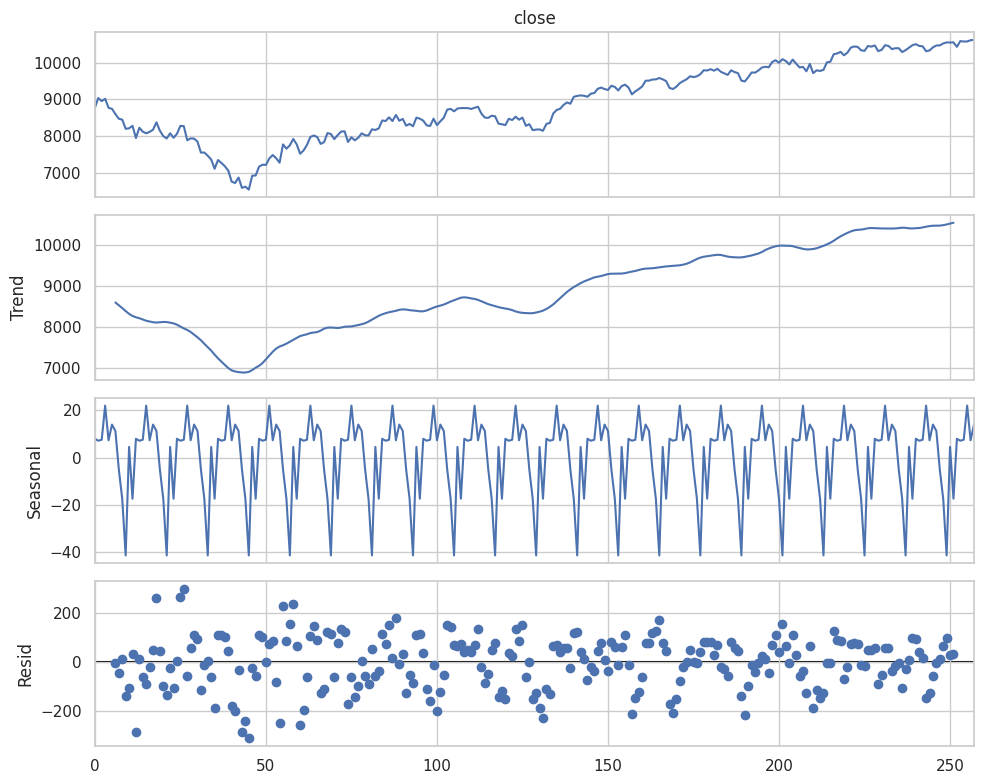

In [56]:

from statsmodels.datasets import co2
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(dow["close"], model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()


## Summary
In this notebook, we converted the main ideas from the R Markdown file into Python:
- moving averages
- LOESS smoothing
- curve fitting
- detrending
- time-series decomposition
